In [4]:
import spatialdata as spd
import spatialdata_plot as splt
import spatialdata_io as so
import geosketch as sketch
import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce

import json
import gc
import geopandas as gpd
from spatialdata.models import Image2DModel, TableModel, ShapesModel
import matplotlib.pyplot as plt

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from PIL import Image
from spatialdata.transformations import Identity, Scale
from shapely.geometry import Polygon


/Users/janzules/miniforge3/envs/vishd_10x/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/janzules/miniforge3/envs/vishd_10x/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/janzules/miniforge3/envs/vishd_10x/lib/python3.11/site-packages/anndata/__init__.py:44: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  return module_

In [5]:
from pathlib import Path
import os

# Variables

In [5]:
# "/Volumes/workl/Jona/spatial/second_run_output/human/F08544/outs/segmented_outputs/"

# sample_name = "F08544"

# sample_dir     = Path(f"/Volumes/workl/Jona/spatial/second_run_output/human/{sample_name}/outs/segmented_outputs/")
# count_matrix   = sample_dir / "filtered_feature_cell_matrix.h5"
# scale_factors  = sample_dir / "spatial" / "scalefactors_json.json"
# geojson_path   = sample_dir / "cell_segmentations.geojson"
# image          = sample_dir / "spatial" / "tissue_hires_image.png"
# # create_zarr(count_matrix,
# #            )


# Functions

In [6]:
def crop0(x,crs,bbox):
    return spd.bounding_box_query(
        x,
        min_coordinate=[bbox['x'][0], bbox['y'][0]],
        max_coordinate=[bbox['x'][1], bbox['y'][1]],
        axes=("x", "y"),
        target_coordinate_system=crs,
    )

In [7]:
def create_zarr(count_matrix_path,
                image_path,
                scale_factors_path,
                geojson_path,
                sample_name,
                output_path
):
    print(sample_name)

    # Load and Prepare Raw Data
    # Define file paths
    COUNT_MATRIX_PATH = count_matrix_path
    IMAGE_PATH = image_path
    SCALE_FACTORS_PATH = scale_factors_path
    GEOJSON_PATH = geojson_path

    # Load AnnData
    adata = sc.read_10x_h5(COUNT_MATRIX_PATH)
    adata.var_names_make_unique()
    adata.obs['sample'] = sample_name
    adata.obs.index = sample_name +"_" + adata.obs.index.astype(str)

    # Load and preprocess image data
    image_data = np.array(Image.open(IMAGE_PATH))
    if image_data.ndim == 2:
        image_data = image_data[np.newaxis, :, :] # Add channel dimension for grayscale
    elif image_data.ndim == 3:
        image_data = np.transpose(image_data, (2, 0, 1)) # (H, W, C) -> (C, H, W) for spatialdata

    # Load scale factors
    with open(SCALE_FACTORS_PATH, 'r') as f:
        scale_data = json.load(f)

    # Load GeoJSON data
    with open(GEOJSON_PATH, 'r') as f:
        geojson_data = json.load(f)

    # Define coordinate systems:
    # `downscale_to_hires`: The coordinate system where shapes are located, scaled relative to the hires resolution.

    hires_scale = scale_data['tissue_hires_scalef']

    # Transformation for shapes (from pixel to downscale_to_hires)
    shapes_transformations = {
       "downscale_to_hires": Scale(np.array([hires_scale, hires_scale]), axes=("x", "y")) # if the high-resolution microscope image is being used and Identity() transform would be performed.
    }

    # Transformation for the 'hires_tissue_image' (it's already in the 'downscale_to_hires' space visually)
    image_transformations = {
        "downscale_to_hires": Identity()
    }

    # Process Cell Segmentation (GeoJSON) and Integrate with AnnData

    # Create a mapping from adata.obs.index to geojson features
    geojson_features_map = {
        f"{sample_name}_cellid_{feature['properties']['cell_id']:09d}-1": feature
        for feature in geojson_data['features']
    }

    # Prepare data for GeoDataFrame and update adata.obs
    geometries = []
    cell_ids_ordered = []

    for obs_index_str in adata.obs.index:
        feature = geojson_features_map.get(obs_index_str)
        if feature:
            # Create shapely Polygon from coordinates
            polygon_coords = np.array(feature['geometry']['coordinates'][0])
            geometries.append(Polygon(polygon_coords))
            cell_ids_ordered.append(obs_index_str)
        else:
            geometries.append(None) # Or a suitable placeholder
            cell_ids_ordered.append(obs_index_str)

    # Remove None entries if any (or handle them upstream)
    valid_indices = [i for i, geom in enumerate(geometries) if geom is not None]
    geometries = [geometries[i] for i in valid_indices]
    cell_ids_ordered = [cell_ids_ordered[i] for i in valid_indices]


    # Create GeoDataFrame for shapes
    shapes_gdf = gpd.GeoDataFrame({
        'cell_id': cell_ids_ordered,
        'geometry': geometries
    }, index=cell_ids_ordered)
    # Update adata.obs with cluster information and spatial identifiers
    adata.obs['cell_id'] = adata.obs.index
    adata.obs['region'] = sample_name + '_cell_boundaries'
    adata.obs['region'] = adata.obs['region'].astype('category')
    adata = adata[shapes_gdf.index].copy() # Filter adata to match shapes_gdf

    # Define names for SpatialData elements
    IMAGE_KEY =  sample_name + '_hires_tissue_image'
    TABLE_KEY =  'segmentation_counts'
    SHAPES_KEY = sample_name + '_cell_boundaries'

    # Create SpatialData elements directly
    sdata = spd.SpatialData(
        images={
            IMAGE_KEY: Image2DModel.parse(image_data, transformations=image_transformations)
        },
        tables={
            TABLE_KEY: TableModel.parse(
                adata,
                region=SHAPES_KEY, # Link table to shapes element
                region_key='region', # Column in adata.obs indicating region name
                instance_key='cell_id' # Column in adata.obs with instance IDs (cell_id)
            )
        },
        shapes={
            SHAPES_KEY: ShapesModel.parse(shapes_gdf, transformations=shapes_transformations)
        }
    )

    sample_output = output_path / sample_name
    sdata.write(sample_output, overwrite=True)
    del sdata
    gc.collect()


# All Zarr

## Creating Zarr

In [51]:
samples = {
    "F07839_1n2",
    "F07840_1n2",
    "F08542",
    "F08543"
}

mouse_out = Path("/Volumes/workl/Jona/spatial/second_run_output/mouse")
out_loc    = Path("/Users/janzules/Roselab/Spatial/CAR_T/data/zarrFiles")

print("Saving zarr files")
for key in samples:  # iterate over keys; we'll replace values
    BASE     = mouse_out / key / "outs" / "segmented_outputs"
    MATRIX   = BASE / "filtered_feature_cell_matrix.h5"
    IMAGE    = BASE / "spatial" / "tissue_hires_image.png"
    SCALE    = BASE / "spatial" / "scalefactors_json.json"
    CELLSEG  = BASE / "cell_segmentations.geojson"
    
    # print(BASE / "filtered_feature_cell_matrix.h5")
    # print(MATRIX.exists())
    # print(BASE / "spatial" / "tissue_hires_image.png")
    # print(IMAGE.exists())
    # print(BASE / "spatial" / "scalefactors_json.json")
    # print(SCALE.exists())
    # print(BASE / "cell_segmentations.geojson")
    # print(CELLSEG.exists())
    # print(key.split("_")[0])
    create_zarr(count_matrix_path=MATRIX,
                image_path=IMAGE,
                scale_factors_path=SCALE,
                geojson_path=CELLSEG,
                sample_name=key.split("_")[0],
                output_path=out_loc
               )
    

    

del key, samples
gc.collect()
    


Saving zarr files
F08543


/Users/janzules/miniforge3/envs/vishd_10x/lib/python3.11/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/janzules/miniforge3/envs/vishd_10x/lib/python3.11/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


INFO     no axes information specified in the object, setting `dims` to: ('c', 'y', 'x')                           
INFO     The Zarr backing store has been changed from None the new file path:                                      
         /Users/janzules/Roselab/Spatial/CAR_T/data/zarrFiles/F08543                                               
F07840


/Users/janzules/miniforge3/envs/vishd_10x/lib/python3.11/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/janzules/miniforge3/envs/vishd_10x/lib/python3.11/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


INFO     no axes information specified in the object, setting `dims` to: ('c', 'y', 'x')                           
INFO     The Zarr backing store has been changed from None the new file path:                                      
         /Users/janzules/Roselab/Spatial/CAR_T/data/zarrFiles/F07840                                               
F08542


/Users/janzules/miniforge3/envs/vishd_10x/lib/python3.11/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/janzules/miniforge3/envs/vishd_10x/lib/python3.11/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


INFO     no axes information specified in the object, setting `dims` to: ('c', 'y', 'x')                           
INFO     The Zarr backing store has been changed from None the new file path:                                      
         /Users/janzules/Roselab/Spatial/CAR_T/data/zarrFiles/F08542                                               
F07839


/Users/janzules/miniforge3/envs/vishd_10x/lib/python3.11/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/janzules/miniforge3/envs/vishd_10x/lib/python3.11/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


INFO     no axes information specified in the object, setting `dims` to: ('c', 'y', 'x')                           
INFO     The Zarr backing store has been changed from None the new file path:                                      
         /Users/janzules/Roselab/Spatial/CAR_T/data/zarrFiles/F07839                                               


0

## Concatenating

In [9]:
zarr_folder = Path("/Users/janzules/Roselab/Spatial/CAR_T/data/zarrFiles")
samples = {
    "F07839_1n2",
    "F07840_1n2",
    "F08542",
    "F08543"
}

mouse_out = Path("/Volumes/workl/Jona/spatial/second_run_output/mouse")
out_loc    = Path("/Users/janzules/Roselab/Spatial/CAR_T/data/zarrFiles")
# Loading the zarr files

visium_hd_zarr_paths = {
    "F07839" : zarr_folder / "F07839",
    "F07840" : zarr_folder / "F07840",
    "F08542" : zarr_folder / "F08542",
    "F08543" : zarr_folder / "F08543"
}

concat_out = zarr_folder / "concatenated_sdata"

In [ ]:
# Loading samples into a dictionary
sdatas = []
for key, path in visium_hd_zarr_paths.items():
    sdata = spd.read_zarr(path)

    for table in sdata.tables.values():
        table.var_names_make_unique()
        table.obs["sample"] = key

    sdatas.append(sdata)
    del sdata, table
    gc.collect()
# Concatenate
concatenated_sdata = spd.concatenate(sdatas, concatenate_tables=True)

concatenated_sdata.write(concat_out, overwrite=True)

del concatenated_sdata,sdatas,visium_hd_zarr_paths, key, path
gc.collect()

concatenated_sdata = spd.read_zarr(concat_out)

print("---------------------------------")
print(concatenated_sdata)

version mismatch: detected: RasterFormatV02, requested: FormatV04
/Users/janzules/miniforge3/envs/vishd_10x/lib/python3.11/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
version mismatch: detected: RasterFormatV02, requested: FormatV04
/Users/janzules/miniforge3/envs/vishd_10x/lib/python3.11/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
version mismatch: detected: RasterFormatV02, requested: FormatV04
/Users/janzules/miniforge3/envs/vishd_10x/lib/python3.11/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
version mismatch: detected: RasterFormatV02, requested: FormatV04
/Users/janzules/miniforge3/envs/vishd_10x/lib/python3.11/site-packages/zarr/creati

INFO     The SpatialData object is not self-contained (i.e. it contains some elements that are Dask-backed from    
         locations outside /Users/janzules/Roselab/Spatial/CAR_T/data/zarrFiles/concatenated_sdata). Please see the
         documentation of `is_self_contained()` to understand the implications of working with SpatialData objects 
         that are not self-contained.                                                                              
INFO     The Zarr backing store has been changed from None the new file path:                                      
         /Users/janzules/Roselab/Spatial/CAR_T/data/zarrFiles/concatenated_sdata                                   


version mismatch: detected: RasterFormatV02, requested: FormatV04
/Users/janzules/miniforge3/envs/vishd_10x/lib/python3.11/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
version mismatch: detected: RasterFormatV02, requested: FormatV04
version mismatch: detected: RasterFormatV02, requested: FormatV04
version mismatch: detected: RasterFormatV02, requested: FormatV04


---------------------------------
SpatialData object, with associated Zarr store: /Users/janzules/Roselab/Spatial/CAR_T/data/zarrFiles/concatenated_sdata
├── Images
│     ├── 'F07839_hires_tissue_image': DataArray[cyx] (3, 6000, 5227)
│     ├── 'F07840_hires_tissue_image': DataArray[cyx] (3, 6000, 5928)
│     ├── 'F08542_hires_tissue_image': DataArray[cyx] (3, 5954, 6000)
│     └── 'F08543_hires_tissue_image': DataArray[cyx] (3, 5652, 6000)
├── Shapes
│     ├── 'F07839_cell_boundaries': GeoDataFrame shape: (178991, 2) (2D shapes)
│     ├── 'F07840_cell_boundaries': GeoDataFrame shape: (124891, 2) (2D shapes)
│     ├── 'F08542_cell_boundaries': GeoDataFrame shape: (66043, 2) (2D shapes)
│     └── 'F08543_cell_boundaries': GeoDataFrame shape: (58897, 2) (2D shapes)
└── Tables
      └── 'segmentation_counts': AnnData (428822, 19059)
with coordinate systems:
    ▸ 'downscale_to_hires', with elements:
        F07839_hires_tissue_image (Images), F07840_hires_tissue_image (Images), F08542_hir

In [65]:
type(concatenated_sdata)

spatialdata._core.spatialdata.SpatialData

In [10]:
concatenated_sdata = spd.read_zarr(concat_out)

version mismatch: detected: RasterFormatV02, requested: FormatV04
/Users/janzules/miniforge3/envs/vishd_10x/lib/python3.11/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
version mismatch: detected: RasterFormatV02, requested: FormatV04
version mismatch: detected: RasterFormatV02, requested: FormatV04
version mismatch: detected: RasterFormatV02, requested: FormatV04


# Visualizing

Plotting: F07839_hires_tissue_image
INFO     Rasterizing image for faster rendering.                                                                   
INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                


/Users/janzules/miniforge3/envs/vishd_10x/lib/python3.11/site-packages/spatialdata/_core/_elements.py:105: UserWarning: Key `F07839_cell_boundaries` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/Users/janzules/miniforge3/envs/vishd_10x/lib/python3.11/site-packages/spatialdata/_core/_elements.py:125: UserWarning: Key `segmentation_counts` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


Plotting: F07840_hires_tissue_image
INFO     Rasterizing image for faster rendering.                                                                   
INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                


/Users/janzules/miniforge3/envs/vishd_10x/lib/python3.11/site-packages/spatialdata/_core/_elements.py:105: UserWarning: Key `F07840_cell_boundaries` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/Users/janzules/miniforge3/envs/vishd_10x/lib/python3.11/site-packages/spatialdata/_core/_elements.py:125: UserWarning: Key `segmentation_counts` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


Plotting: F08542_hires_tissue_image
INFO     Rasterizing image for faster rendering.                                                                   
INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                


/Users/janzules/miniforge3/envs/vishd_10x/lib/python3.11/site-packages/spatialdata/_core/_elements.py:105: UserWarning: Key `F08542_cell_boundaries` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/Users/janzules/miniforge3/envs/vishd_10x/lib/python3.11/site-packages/spatialdata/_core/_elements.py:125: UserWarning: Key `segmentation_counts` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


Plotting: F08543_hires_tissue_image
INFO     Rasterizing image for faster rendering.                                                                   
INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                


/Users/janzules/miniforge3/envs/vishd_10x/lib/python3.11/site-packages/spatialdata/_core/_elements.py:105: UserWarning: Key `F08543_cell_boundaries` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)
/Users/janzules/miniforge3/envs/vishd_10x/lib/python3.11/site-packages/spatialdata/_core/_elements.py:125: UserWarning: Key `segmentation_counts` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


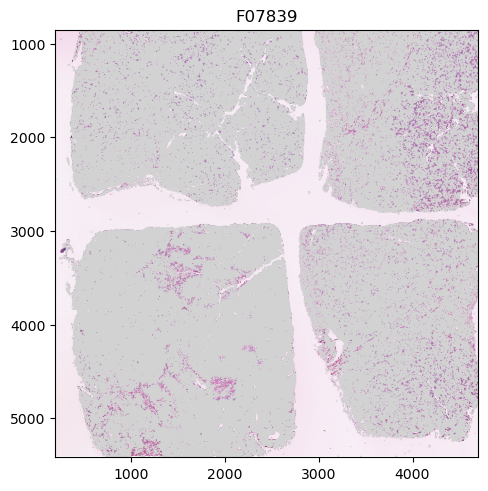

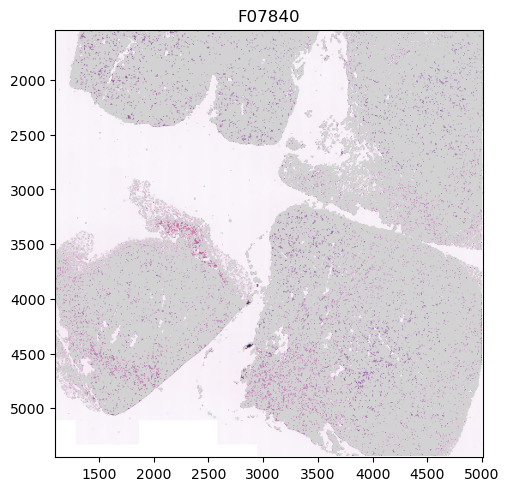

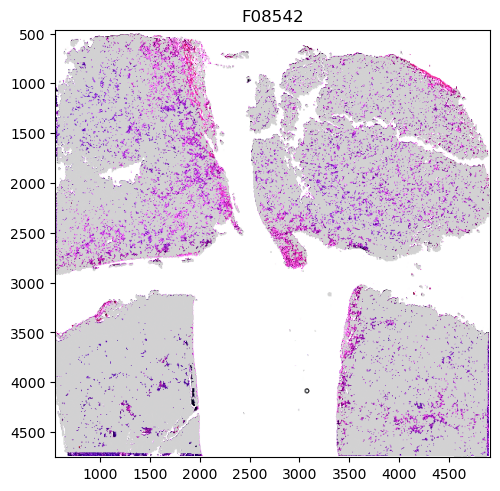

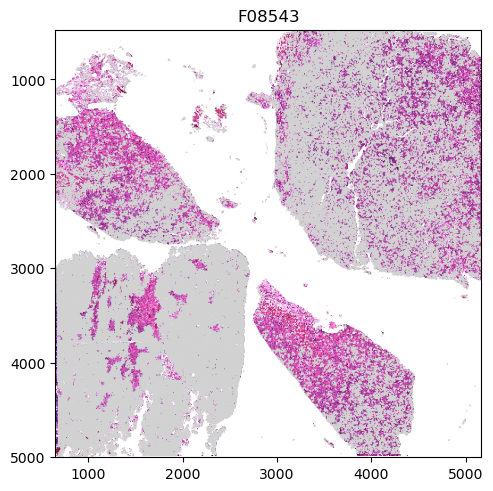

In [11]:
image_elements = list(concatenated_sdata.images.keys())
shape_elements = list(concatenated_sdata.shapes.keys())

# We are going to create a bounding box to crop the data to the capture area.
extents = []

for i in range(len(image_elements)):
    extent =  spd.get_extent(concatenated_sdata,elements=[shape_elements[i]],coordinate_system='downscale_to_hires')
    extents.append(extent)

# Plotting
if len(image_elements) != len(shape_elements):
    print("Check the spatial data to make sure that for every image there is a shape")
else:
    for i in range(len(image_elements)):
        print("Plotting: "+ image_elements[i])
        title=image_elements[i].replace("_hires_tissue_image","")
        crop0(concatenated_sdata,crs="downscale_to_hires",bbox=extents[i]).pl.render_images(image_elements[i]).pl.render_shapes(shape_elements[i],color="clusters").pl.show(coordinate_systems="downscale_to_hires", title=title)


# QC

In [61]:
adata = concatenated_sdata["segmentation_counts"] # we link the AnnData Table in the SpatialData object to the variable adata to make the code easier to read
adata

AnnData object with n_obs × n_vars = 428822 × 19059
    obs: 'sample', 'cell_id', 'region'
    uns: 'spatialdata_attrs'

# Testing

In [103]:
out_loc.exists()

True

## adata

In [88]:
# Load AnnData
adata = sc.read_10x_h5(count_matrix)
adata.var_names_make_unique()
adata.obs['sample'] = sample_name
adata.obs.index = sample_name +"_" + adata.obs.index.astype(str)

/Users/janzules/miniforge3/envs/vishd_10x/lib/python3.11/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/janzules/miniforge3/envs/vishd_10x/lib/python3.11/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [68]:
adata = sc.read_10x_h5(count_matrix)

/Users/janzules/miniforge3/envs/vishd_10x/lib/python3.11/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/janzules/miniforge3/envs/vishd_10x/lib/python3.11/site-packages/anndata/_core/anndata.py:1776: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [69]:
adata.var_names_make_unique()

In [91]:
adata.obs.index[0:4]

Index(['F08544_cellid_000000001-1', 'F08544_cellid_000000002-1',
       'F08544_cellid_000000003-1', 'F08544_cellid_000000004-1'],
      dtype='object')

In [89]:
adata.obs

,sample
F08544_cellid_000000001-1,F08544
F08544_cellid_000000002-1,F08544
F08544_cellid_000000003-1,F08544
F08544_cellid_000000004-1,F08544
F08544_cellid_000000005-1,F08544
...,...
F08544_cellid_000067750-1,F08544
F08544_cellid_000067751-1,F08544
F08544_cellid_000067752-1,F08544
F08544_cellid_000067753-1,F08544


## Geojson

In [10]:
with open(scale_factors, 'r') as f:
    scale_data = json.load(f)

In [16]:
with open(geojson_path, 'r') as f:
    geojson = json.load(f)

In [58]:
geojson.keys()

dict_keys(['type', 'features'])

In [59]:
from collections import Counter

In [60]:
assert geojson['type'] == 'FeatureCollection'

In [62]:
features = geojson["features"]
len(features)

66930

In [92]:
features[0]['properties']

{'cell_id': 1}

In [93]:
 geojson_features_map = {
        f"{sample_name}_cellid_{feature['properties']['cell_id']:09d}-1": feature
        for feature in geojson['features']
    }

In [83]:
a = [feature for feature in geojson['features'][0:4]]

In [84]:
len(a)

4

In [87]:
a['properties']['cell_id']

TypeError: list indices must be integers or slices, not str

In [74]:
geojson['features'][0]['properties']['cell_id']

1

In [53]:
geojson['features'][0]
# ['properties']['cell_id']

{'type': 'Feature',
 'geometry': {'type': 'Polygon',
  'coordinates': [[[2081.4, 2974.4],
    [2084.3, 2974.4],
    [2084.3, 2971.5],
    [2090.1, 2971.4],
    [2090.1, 2968.5],
    [2093.0, 2968.5],
    [2092.9, 2965.6],
    [2095.8, 2965.5],
    [2095.9, 2968.5],
    [2098.8, 2968.4],
    [2098.8, 2971.3],
    [2101.7, 2971.3],
    [2101.8, 2974.2],
    [2104.7, 2974.2],
    [2104.7, 2977.1],
    [2107.6, 2977.0],
    [2107.6, 2980.0],
    [2110.6, 2979.9],
    [2110.6, 2982.8],
    [2113.5, 2982.8],
    [2113.5, 2985.7],
    [2110.6, 2985.7],
    [2110.7, 2991.6],
    [2096.1, 2991.7],
    [2096.2, 2994.6],
    [2093.3, 2994.7],
    [2093.2, 2991.8],
    [2090.3, 2991.8],
    [2090.3, 2986.0],
    [2087.3, 2986.0],
    [2087.3, 2983.1],
    [2084.4, 2983.1],
    [2084.4, 2980.2],
    [2081.5, 2980.3],
    [2081.4, 2974.4]]]},
 'properties': {'cell_id': 1}}

In [46]:
maps = {
        f"{sample_name}_cellid_{feature['properties']['cell_id']:09d}-1": feature
        for feature in geojson['features']
    }

In [47]:
maps

{'F08544_cellid_000000001-1': {'type': 'Feature',
  'geometry': {'type': 'Polygon',
   'coordinates': [[[2081.4, 2974.4],
     [2084.3, 2974.4],
     [2084.3, 2971.5],
     [2090.1, 2971.4],
     [2090.1, 2968.5],
     [2093.0, 2968.5],
     [2092.9, 2965.6],
     [2095.8, 2965.5],
     [2095.9, 2968.5],
     [2098.8, 2968.4],
     [2098.8, 2971.3],
     [2101.7, 2971.3],
     [2101.8, 2974.2],
     [2104.7, 2974.2],
     [2104.7, 2977.1],
     [2107.6, 2977.0],
     [2107.6, 2980.0],
     [2110.6, 2979.9],
     [2110.6, 2982.8],
     [2113.5, 2982.8],
     [2113.5, 2985.7],
     [2110.6, 2985.7],
     [2110.7, 2991.6],
     [2096.1, 2991.7],
     [2096.2, 2994.6],
     [2093.3, 2994.7],
     [2093.2, 2991.8],
     [2090.3, 2991.8],
     [2090.3, 2986.0],
     [2087.3, 2986.0],
     [2087.3, 2983.1],
     [2084.4, 2983.1],
     [2084.4, 2980.2],
     [2081.5, 2980.3],
     [2081.4, 2974.4]]]},
  'properties': {'cell_id': 1}},
 'F08544_cellid_000000002-1': {'type': 'Feature',
  'geometr

In [44]:
geojson['features']

[{'type': 'Feature',
  'geometry': {'type': 'Polygon',
   'coordinates': [[[2081.4, 2974.4],
     [2084.3, 2974.4],
     [2084.3, 2971.5],
     [2090.1, 2971.4],
     [2090.1, 2968.5],
     [2093.0, 2968.5],
     [2092.9, 2965.6],
     [2095.8, 2965.5],
     [2095.9, 2968.5],
     [2098.8, 2968.4],
     [2098.8, 2971.3],
     [2101.7, 2971.3],
     [2101.8, 2974.2],
     [2104.7, 2974.2],
     [2104.7, 2977.1],
     [2107.6, 2977.0],
     [2107.6, 2980.0],
     [2110.6, 2979.9],
     [2110.6, 2982.8],
     [2113.5, 2982.8],
     [2113.5, 2985.7],
     [2110.6, 2985.7],
     [2110.7, 2991.6],
     [2096.1, 2991.7],
     [2096.2, 2994.6],
     [2093.3, 2994.7],
     [2093.2, 2991.8],
     [2090.3, 2991.8],
     [2090.3, 2986.0],
     [2087.3, 2986.0],
     [2087.3, 2983.1],
     [2084.4, 2983.1],
     [2084.4, 2980.2],
     [2081.5, 2980.3],
     [2081.4, 2974.4]]]},
  'properties': {'cell_id': 1}},
 {'type': 'Feature',
  'geometry': {'type': 'Polygon',
   'coordinates': [[[3157.5, 2924.

In [43]:
scale_data['tissue_hires_scalef']

0.53816485

In [39]:
all_keys = {k for feat in geojson['features'] for k in feat.keys()}

In [40]:
all_keys

{'geometry', 'properties', 'type'}

In [38]:
geojson['features'][0]['geometry'].keys()

dict_keys(['type', 'coordinates'])

In [37]:
geojson['features'][0]['geometry']['type']

'Polygon'

In [21]:
geojson

{'type': 'FeatureCollection',
 'features': [{'type': 'Feature',
   'geometry': {'type': 'Polygon',
    'coordinates': [[[2081.4, 2974.4],
      [2084.3, 2974.4],
      [2084.3, 2971.5],
      [2090.1, 2971.4],
      [2090.1, 2968.5],
      [2093.0, 2968.5],
      [2092.9, 2965.6],
      [2095.8, 2965.5],
      [2095.9, 2968.5],
      [2098.8, 2968.4],
      [2098.8, 2971.3],
      [2101.7, 2971.3],
      [2101.8, 2974.2],
      [2104.7, 2974.2],
      [2104.7, 2977.1],
      [2107.6, 2977.0],
      [2107.6, 2980.0],
      [2110.6, 2979.9],
      [2110.6, 2982.8],
      [2113.5, 2982.8],
      [2113.5, 2985.7],
      [2110.6, 2985.7],
      [2110.7, 2991.6],
      [2096.1, 2991.7],
      [2096.2, 2994.6],
      [2093.3, 2994.7],
      [2093.2, 2991.8],
      [2090.3, 2991.8],
      [2090.3, 2986.0],
      [2087.3, 2986.0],
      [2087.3, 2983.1],
      [2084.4, 2983.1],
      [2084.4, 2980.2],
      [2081.5, 2980.3],
      [2081.4, 2974.4]]]},
   'properties': {'cell_id': 1}},
  {'type'

In [ ]:
    # Load scale factors
    with open(SCALE_FACTORS_PATH, 'r') as f:
        scale_data = json.load(f)

    # Load GeoJSON data
    with open(GEOJSON_PATH, 'r') as f:
        geojson_data = json.load(f)

In [6]:
image

PosixPath('/Volumes/workl/Jona/spatial/second_run_output/human/F08544/outs/segmented_outputs/spatial/tissue_hires_image.png')

In [8]:
image_data = np.array(Image.open(image))

In [9]:
image_data.ndim

3

In [ ]:
# Load and preprocess image data
image_data = np.array(Image.open(IMAGE_PATH))
if image_data.ndim == 2:
    image_data = image_data[np.newaxis, :, :] # Add channel dimension for grayscale
elif image_data.ndim == 3:
    image_data = np.transpose(image_data, (2, 0, 1)) # (H, W, C) -> (C, H, W) for spatialdata